In [18]:
%matplotlib inline
import subprocess, sys
# packages = [
#     "pandas", "numpy", "matplotlib", "seaborn",
#     "scikit-learn", "gensim", "nltk",
#     "PySastrawi", "wordcloud", "pyLDAvis"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

1. IMPORT LIBRARY

In [19]:
import os
import re
import time
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess

import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
    StopWordRemoverFactory, ArrayDictionary
)

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)
nltk.download('punkt', quiet=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("  TOPIC MODELING: LDA vs NMF — Berita Online Indonesia")
print("=" * 60)

  TOPIC MODELING: LDA vs NMF — Berita Online Indonesia


2. KONFIGURASI PARAMETER

In [20]:
class Config:
    # ── Path file ──────────────────────────────────────────────
    DATASET_PATH   = "lda_nmf.csv"
    OUTPUT_DIR     = "output_hasil"
 
    # ── Kolom dataset ──────────────────────────────────────────
    COL_ID         = "id_berita"
    COL_JUDUL      = "judul"
    COL_ISI        = "isi_berita"
    COL_KATEGORI   = "kategori"
 
    # ── Parameter model ────────────────────────────────────────
    N_TOPICS       = 4          # K = 4 (sesuai 4 kategori)
    N_TOP_WORDS    = 10         # kata dominan per topik
    MAX_FEATURES   = 10_000     # batas fitur TF-IDF
 
    # ── Parameter LDA ──────────────────────────────────────────
    LDA_PASSES     = 20
    LDA_ITERATIONS = 50
    LDA_ALPHA      = 0.1     # bisa diganti float mis. 0.1
    LDA_ETA        = 0.01     # betas
 
    # ── Parameter NMF ──────────────────────────────────────────
    NMF_INIT       = "random"   
    NMF_MAX_ITER   = 200
    NMF_SOLVER     = "cd"       # coordinate descent
 
    # ── TF-IDF ─────────────────────────────────────────────────
    TFIDF_MIN_DF   = 5          
    TFIDF_MAX_DF   = 0.90       # abaikan kata yang muncul di > 90% dokumen
    TFIDF_NGRAM    = (1, 1)     # unigram
 
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
 

3.  MEMUAT DATASET

In [21]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Memuat dataset berita dari file CSV.
 
    Format kolom yang diharapkan:
        id_berita | judul | isi_berita | kategori
 
    Jika file tidak ditemukan atau kolom tidak sesuai,
    fungsi akan langsung menampilkan pesan error yang jelas.
    """
    # ── Cek keberadaan file ───────────────────────────────────────────────────
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\n[ERROR] File dataset tidak ditemukan: '{path}'\n"
            f"        Pastikan file CSV sudah ada di lokasi tersebut,\n"
            f"        atau ubah Config.DATASET_PATH sesuai lokasi file kamu."
        )
 
    # ── Baca CSV ──────────────────────────────────────────────────────────────
    df = pd.read_csv(path, encoding="utf-8")
    print(f"[✓] Dataset berhasil dimuat: {len(df):,} baris dari '{path}'")
 
    # ── Validasi kolom yang diperlukan ────────────────────────────────────────
    required = [Config.COL_ID, Config.COL_ISI, Config.COL_KATEGORI]
    for col in required:
        if col not in df.columns:
            raise ValueError(
                f"\n[ERROR] Kolom '{col}' tidak ditemukan dalam dataset!\n"
                f"        Kolom yang tersedia : {list(df.columns)}\n"
                f"        Sesuaikan nama kolom di bagian Config (COL_ID, COL_ISI, COL_KATEGORI)."
            )
 
    # ── Hapus baris dengan nilai kosong ───────────────────────────────────────
    awal = len(df)
    df[Config.COL_ISI] = df[Config.COL_ISI].astype(str)
    df.dropna(subset=[Config.COL_ISI, Config.COL_KATEGORI], inplace=True)
    df.reset_index(drop=True, inplace=True)
    if len(df) < awal:
        print(f"[!] {awal - len(df)} baris dihapus karena nilai kosong (missing value).")
 
    # ── Tampilkan distribusi kategori ─────────────────────────────────────────
    print(f"\n    Distribusi kategori:")
    for kat, n in df[Config.COL_KATEGORI].value_counts().items():
        print(f"      {kat:<15}: {n:,} dokumen")
 
    return df
 
 
print("\n[STEP 1] Memuat Dataset...")
df = load_dataset(Config.DATASET_PATH)


[STEP 1] Memuat Dataset...
[✓] Dataset berhasil dimuat: 4,000 baris dari 'lda_nmf.csv'

    Distribusi kategori:
      politik        : 1,000 dokumen
      ekonomi        : 1,000 dokumen
      teknologi      : 1,000 dokumen
      olahraga       : 1,000 dokumen


4. TEXT PREPROCESSING

In [22]:
print("\n[STEP 2] Preprocessing Teks...")

# ── 4.1 Inisialisasi Stemmer & Stopword Remover (PySastrawi) ─────────────────
factory_stemmer   = StemmerFactory()
stemmer           = factory_stemmer.create_stemmer()

factory_stopword  = StopWordRemoverFactory()
stopword_list_id  = factory_stopword.get_stop_words()

# Tambahkan stopword kustom yang relevan untuk berita online
EXTRA_STOPWORDS = {
    "quot", "amp", "yang", "juga", "ini", "itu", "dan", "atau",
    "di", "ke", "dari", "dengan", "untuk", "pada", "adalah", "akan",
    "oleh", "dalam", "tidak", "telah", "sudah", "dapat", "bisa",
    "ada", "serta", "namun", "namun", "jika", "bahwa", "saat",
    "antara", "sebuah", "seperti", "lebih", "tersebut", "dimana",
    "hingga", "ketika", "secara", "sama", "setelah", "sebelum",
    "tentang", "menjadi", "sebagai", "sesuai", "berupa", "terkait",
    "menurut", "melalui", "yaitu", "persen", "lain", "dilakukan",
    "kata", "baca", "laku", "lalu", "satu", "dua", "tiga",
    "jakarta", "antara", "detik", "kompas", "cnn",     # artefak scraping
}
all_stopwords = set(stopword_list_id) | EXTRA_STOPWORDS


def cleaning(text: str) -> str:
    """Menghapus karakter tidak relevan dari teks."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)          # URL
    text = re.sub(r'<.*?>', '', text)                    # HTML tag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)            # bukan huruf
    text = re.sub(r'\s+', ' ', text).strip()             # spasi duplicate
    return text


def case_folding(text: str) -> str:
    """Mengubah teks ke huruf kecil (lowercase)."""
    return text.lower()


def tokenizing(text: str) -> list:
    """Memecah teks menjadi token kata (unigram/kata tunggal)."""
    return text.split()


def stopword_removal(tokens: list) -> list:
    """Menghapus stopword dari daftar token kata."""
    return [t for t in tokens if t not in all_stopwords and len(t) > 2]


def stemming_tokens(tokens: list) -> list:
    """Melakukan stemming: mengembalikan kata ke bentuk dasar (misal: 'pemerintahan' → 'perintah')."""
    return [stemmer.stem(t) for t in tokens]


def full_preprocessing(text: str) -> list:
    """Pipeline preprocessing lengkap: cleaning → case folding → tokenizing → stopword removal → stemming."""
    text  = cleaning(text)
    text  = case_folding(text)
    toks  = tokenizing(text)
    toks  = stopword_removal(toks)
    toks  = stemming_tokens(toks)
    toks  = [t for t in toks if len(t) > 2]   # filter token sangat pendek
    return toks


# ── 4.2 Terapkan preprocessing ke seluruh dataset ───────────────────────────
print("   Menerapkan preprocessing (stemming bisa memakan waktu beberapa menit)...")
t0 = time.time()

df["tokens"]         = df[Config.COL_ISI].apply(full_preprocessing)
df["teks_bersih"]    = df["tokens"].apply(lambda t: " ".join(t))
token_list           = df["tokens"].tolist()
df["panjang_asli"]   = df[Config.COL_ISI].apply(lambda x: len(str(x).split()))
df["panjang_bersih"] = df["tokens"].apply(len)

prep_time = time.time() - t0

# ── 4.3 Statistik preprocessing ─────────────────────────────────────────────
all_tokens_before = df[Config.COL_ISI].apply(lambda x: str(x).split()).explode()
all_tokens_after  = df["tokens"].explode()

# ── Contoh hasil tokenisasi (1 dokumen) untuk memperjelas ────────────────────
contoh_idx   = 0
contoh_asli  = str(df[Config.COL_ISI].iloc[contoh_idx])[:120]
contoh_token = df["tokens"].iloc[contoh_idx][:10]

print("\n" + "="*60)
print("   PENJELASAN TOKEN")
print("="*60)
print("   Token = kata tunggal (unigram) hasil pemrosesan teks.")
print("   Setiap kata yang tersisa setelah cleaning, case folding,")
print("   tokenisasi, stopword removal, dan stemming disebut token.")
print()
print("   Contoh proses pada 1 dokumen:")
print(f"   Teks asli    : \"{contoh_asli}...\"")
print(f"   Token hasil  : {contoh_token}")
print("   (setiap elemen dalam list di atas = 1 token kata)")

print("\n" + "="*60)
print("   STATISTIK PREPROCESSING")
print("="*60)
print(f"   {'Keterangan':<48} {'Nilai':>10}")
print("   " + "-"*56)
print(f"   {'Jumlah dokumen berita':<48} {len(df):>10,}")
print(f"   {'Total kata/token SEBELUM preprocessing':<48} {len(all_tokens_before):>10,}")
print(f"   {'Total kata/token SESUDAH preprocessing':<48} {len(all_tokens_after):>10,}")
print(f"   {'Kata unik SEBELUM preprocessing':<48} {all_tokens_before.nunique():>10,}")
print(f"   {'Kata unik SESUDAH preprocessing':<48} {all_tokens_after.nunique():>10,}")
print(f"   {'Rata-rata jumlah kata per dok (sebelum)':<48} {df['panjang_asli'].mean():>10.1f}")
print(f"   {'Rata-rata jumlah token per dok (sesudah)':<48} {df['panjang_bersih'].mean():>10.1f}")
print(f"   {'Jumlah token minimum dalam 1 dokumen':<48} {df['panjang_bersih'].min():>10,}")
print(f"   {'Jumlah token maksimum dalam 1 dokumen':<48} {df['panjang_bersih'].max():>10,}")
print(f"   {'Waktu preprocessing (detik)':<48} {prep_time:>10.2f}")
print("   " + "-"*56)
reduksi = (1 - len(all_tokens_after) / len(all_tokens_before)) * 100
print(f"   {'Reduksi token setelah preprocessing':<48} {reduksi:>9.1f}%")
print("="*60)

# Simpan hasil preprocessing
df[[Config.COL_ID, Config.COL_KATEGORI, "panjang_asli", "panjang_bersih", "teks_bersih"]]\
    .to_csv(f"{Config.OUTPUT_DIR}/hasil_preprocessing.csv", index=False, encoding="utf-8-sig")
print(f"\n   [✓] Hasil preprocessing disimpan ke '{Config.OUTPUT_DIR}/hasil_preprocessing.csv'")

# ── 4.4 Top-20 kata/token setelah preprocessing ──────────────────────────────
freq_after = Counter(all_tokens_after.dropna().tolist())
top20 = freq_after.most_common(20)
print("\n" + "="*60)
print("   TOP-20 TOKEN (KATA) PALING SERING MUNCUL SETELAH PREPROCESSING")
print("   (token = kata tunggal hasil stemming, sudah bebas stopword)")
print("="*60)
print(f"   {'No':<5} {'Token/Kata':<25} {'Frekuensi Kemunculan':>20}")
print("   " + "-"*52)
for rank, (kata, freq) in enumerate(top20, 1):
    print(f"   {rank:<5} {kata:<25} {freq:>20,}")
print("="*60)


[STEP 2] Preprocessing Teks...
   Menerapkan preprocessing (stemming bisa memakan waktu beberapa menit)...

   PENJELASAN TOKEN
   Token = kata tunggal (unigram) hasil pemrosesan teks.
   Setiap kata yang tersisa setelah cleaning, case folding,
   tokenisasi, stopword removal, dan stemming disebut token.

   Contoh proses pada 1 dokumen:
   Teks asli    : "Menteri Sekretaris Negara (Mensesneg) Prasetyo Hadi memastikan tokoh oposisi yang bertemu Presiden Prabowo Subianto pada..."
   Token hasil  : ['menteri', 'sekretaris', 'negara', 'mensesneg', 'prasetyo', 'had', 'tokoh', 'oposisi', 'temu', 'presiden']
   (setiap elemen dalam list di atas = 1 token kata)

   STATISTIK PREPROCESSING
   Keterangan                                            Nilai
   --------------------------------------------------------
   Jumlah dokumen berita                                 4,000
   Total kata/token SEBELUM preprocessing            1,782,194
   Total kata/token SESUDAH preprocessing            1,048,

PERBANDINGAN PEMODELAN TOPIK LDA vs NMF
DENGAN STEMMING vs TANPA STEMMING

In [23]:
"""
PERBANDINGAN PEMODELAN TOPIK LDA vs NMF
DENGAN STEMMING vs TANPA STEMMING

Tujuan: Menjawab pertanyaan dosen penguji apakah hasil lebih baik dengan atau tanpa stemming.
Metrik evaluasi: Topic Coherence (Cv)
"""

RANDOM_SEED = 42
N_TOPICS = 4
N_TOP_WORDS = 10
MAX_FEATURES = 10000

df_comparison = pd.read_csv("lda_nmf.csv", encoding="utf-8")
df_comparison = df_comparison.dropna(subset=["isi_berita", "kategori"]).reset_index(drop=True)
print(f"Dataset: {len(df_comparison)} dokumen\n")

factory_stopword = StopWordRemoverFactory()
stopword_list_id = factory_stopword.get_stop_words()
EXTRA_STOPWORDS = {
    "quot", "amp", "yang", "juga", "ini", "itu", "dan", "atau",
    "di", "ke", "dari", "dengan", "untuk", "pada", "adalah", "akan",
    "oleh", "dalam", "tidak", "telah", "sudah", "dapat", "bisa",
    "ada", "serta", "namun", "jika", "bahwa", "saat", "antara",
    "sebuah", "seperti", "lebih", "tersebut", "dimana", "hingga",
    "ketika", "secara", "sama", "setelah", "sebelum", "tentang",
    "menjadi", "sebagai", "sesuai", "berupa", "terkait", "menurut",
    "melalui", "yaitu", "persen", "lain", "dilakukan", "kata",
    "baca", "laku", "lalu", "satu", "dua", "tiga", "jakarta", "detik", "kompas", "cnn"
}
all_stopwords = set(stopword_list_id) | EXTRA_STOPWORDS

def cleaning_case_folding_tokenizing(text: str) -> list:
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    return tokens

_factory_stemmer = StemmerFactory()
_stemmer         = _factory_stemmer.create_stemmer()
_stem_cache: dict = {}   # cache: kata → hasil stem

def stem_tokens(tokens: list) -> list:
    hasil = []
    for t in tokens:
        if t not in _stem_cache:
            _stem_cache[t] = _stemmer.stem(t)  # stem hanya jika belum pernah
        hasil.append(_stem_cache[t])
    return hasil

results = {}

for use_stemming in [True, False]:
    pipeline_name = "Dengan Stemming" if use_stemming else "Tanpa Stemming"
    print(f"\n{'='*60}")
    print(f"PROSES PIPELINE: {pipeline_name}")
    print('='*60)

    t0 = time.time()
    tokens_list = []
    for text in df_comparison["isi_berita"]:
        tokens = cleaning_case_folding_tokenizing(text)
        if use_stemming:
            tokens = stem_tokens(tokens)
        tokens = [t for t in tokens if len(t) > 2]
        tokens_list.append(tokens)
    prep_time = time.time() - t0
    print(f"Preprocessing selesai: {prep_time:.2f} detik")

    clean_texts = [" ".join(tokens) for tokens in tokens_list]

    vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, min_df=5, max_df=0.90)
    tfidf_matrix = vectorizer.fit_transform(clean_texts)
    vocab = vectorizer.get_feature_names_out()
    print(f"TF-IDF: {tfidf_matrix.shape}")

    id2word = corpora.Dictionary(tokens_list)
    id2word.filter_extremes(no_below=5, no_above=0.90)
    corpus_bow = [id2word.doc2bow(doc) for doc in tokens_list]

    lda_model = LdaModel(
        corpus=corpus_bow, id2word=id2word, num_topics=N_TOPICS,
        random_state=RANDOM_SEED, passes=20, iterations=50,
        alpha=0.1, eta=0.01
    )
    coh_lda = CoherenceModel(model=lda_model, texts=tokens_list, dictionary=id2word, coherence='c_v')
    coherence_lda = coh_lda.get_coherence()

    nmf_model = NMF(n_components=N_TOPICS, init='random', max_iter=200, solver='cd', random_state=RANDOM_SEED)
    W = nmf_model.fit_transform(tfidf_matrix)
    H = nmf_model.components_
    nmf_topics_words = []
    for i in range(N_TOPICS):
        top_idx = H[i].argsort()[::-1][:N_TOP_WORDS]
        words = [vocab[j] for j in top_idx]
        nmf_topics_words.append(words)
    coh_nmf = CoherenceModel(topics=nmf_topics_words, texts=tokens_list, dictionary=id2word, coherence='c_v')
    coherence_nmf = coh_nmf.get_coherence()

    results[pipeline_name] = {
        "LDA_Coherence": coherence_lda,
        "NMF_Coherence": coherence_nmf,
        "Waktu_Preprocessing": prep_time,
        "Contoh_Topik_LDA": [lda_model.show_topic(i, topn=5) for i in range(N_TOPICS)],
        "Contoh_Topik_NMF": nmf_topics_words
    }

    print(f"LDA Coherence (Cv) : {coherence_lda:.4f}")
    print(f"NMF Coherence (Cv) : {coherence_nmf:.4f}")

print("\n" + "="*70)
print("KESIMPULAN:")
print("="*70)

if results["Dengan Stemming"]["LDA_Coherence"] > results["Tanpa Stemming"]["LDA_Coherence"]:
    print("LDA menunjukkan Topic Coherence (Cv) lebih tinggi dengan stemming")
else:
    print("LDA menunjukkan Topic Coherence (Cv) lebih tinggi tanpa stemming")

if results["Dengan Stemming"]["NMF_Coherence"] > results["Tanpa Stemming"]["NMF_Coherence"]:
    print("NMF menunjukkan Topic Coherence (Cv) lebih tinggi dengan stemming")
else:
    print("NMF menunjukkan Topic Coherence (Cv) lebih tinggi tanpa stemming")

print("\nCatatan:")
print(
f"  - LDA : "
f"{results['Dengan Stemming']['LDA_Coherence']:.4f} (stemming) vs "
f"{results['Tanpa Stemming']['LDA_Coherence']:.4f} (tanpa stemming)"
)

print(
f"  - NMF : "
f"{results['Dengan Stemming']['NMF_Coherence']:.4f} (stemming) vs "
f"{results['Tanpa Stemming']['NMF_Coherence']:.4f} (tanpa stemming)"
)

print("  - Pengaruh stemming berbeda pada setiap metode pemodelan topik.")
print("  - Pemilihan pipeline akhir tidak ditentukan berdasarkan konsistensi preprocessing,")
print("    tetapi berdasarkan hasil evaluasi Topic Coherence (Cv)")
print("    dan interpretasi kualitas topik yang dihasilkan.")


Dataset: 4000 dokumen


PROSES PIPELINE: Dengan Stemming
Preprocessing selesai: 17.84 detik
TF-IDF: (4000, 8903)
LDA Coherence (Cv) : 0.4830
NMF Coherence (Cv) : 0.7645

PROSES PIPELINE: Tanpa Stemming
Preprocessing selesai: 3.33 detik
TF-IDF: (4000, 10000)
LDA Coherence (Cv) : 0.4751
NMF Coherence (Cv) : 0.8071

KESIMPULAN:
LDA menunjukkan Topic Coherence (Cv) lebih tinggi dengan stemming
NMF menunjukkan Topic Coherence (Cv) lebih tinggi tanpa stemming

Catatan:
  - LDA : 0.4830 (stemming) vs 0.4751 (tanpa stemming)
  - NMF : 0.7645 (stemming) vs 0.8071 (tanpa stemming)
  - Pengaruh stemming berbeda pada setiap metode pemodelan topik.
  - Pemilihan pipeline akhir tidak ditentukan berdasarkan konsistensi preprocessing,
    tetapi berdasarkan hasil evaluasi Topic Coherence (Cv)
    dan interpretasi kualitas topik yang dihasilkan.


5. REPRESENTASI TF-IDF

In [24]:
print("\n[STEP 3] Representasi TF-IDF...")
 
tfidf_vectorizer = TfidfVectorizer(
    max_features = Config.MAX_FEATURES,
    min_df       = Config.TFIDF_MIN_DF,
    max_df       = Config.TFIDF_MAX_DF,
    ngram_range  = Config.TFIDF_NGRAM,
)
 
tfidf_matrix = tfidf_vectorizer.fit_transform(df["teks_bersih"])
vocab        = tfidf_vectorizer.get_feature_names_out()
 
print(f"   Dimensi matriks TF-IDF : {tfidf_matrix.shape[0]:,} baris × {tfidf_matrix.shape[1]:,} kolom")
print(f"   Ukuran kosakata (vocab) : {len(vocab):,} kata")
print(f"   Tingkat kejarangan (sparsity): {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")
 
# Top-5 kata TF-IDF tertinggi per kategori
print("\n   === TOP-5 KATA TF-IDF PER KATEGORI ===")
top_words_per_cat = {}
for kategori in df[Config.COL_KATEGORI].unique():
    idx      = df[df[Config.COL_KATEGORI] == kategori].index
    sub_mat  = tfidf_matrix[idx]
    mean_tfidf = np.asarray(sub_mat.mean(axis=0)).flatten()
    top_idx  = mean_tfidf.argsort()[::-1][:5]
    top_words_per_cat[kategori] = [(vocab[i], round(mean_tfidf[i], 4)) for i in top_idx]
    print(f"   [{kategori.upper()}] → {[w for w,_ in top_words_per_cat[kategori]]}")
 
pd.DataFrame(
    {k: [w for w,_ in v] for k, v in top_words_per_cat.items()}
).to_csv(f"{Config.OUTPUT_DIR}/hasil_tfidf_topwords.csv", index=False, encoding="utf-8-sig")


[STEP 3] Representasi TF-IDF...
   Dimensi matriks TF-IDF : 4,000 baris × 8,903 kolom
   Ukuran kosakata (vocab) : 8,903 kata
   Tingkat kejarangan (sparsity): 98.3653%

   === TOP-5 KATA TF-IDF PER KATEGORI ===
   [POLITIK] → ['prabowo', 'presiden', 'perintah', 'negara', 'dpr']
   [EKONOMI] → ['ekonomi', 'tumbuh', 'harga', 'indonesia', 'ojk']
   [TEKNOLOGI] → ['teknologi', 'digital', 'misi', 'nasa', 'teliti']
   [OLAHRAGA] → ['piala', 'indonesia', 'main', 'final', 'olahraga']


DETEKSI BERITA DUPLIKAT (Berita dengan Isi Sama)

In [25]:
print("\n" + "="*65)
print("  DETEKSI BERITA DUPLIKAT")
print("="*65)

# === METODE A: Duplikat PERSIS (isi_berita identik) ===
duplikat_eksak = df[df.duplicated(subset=[Config.COL_ISI], keep=False)].copy()
duplikat_eksak = duplikat_eksak.sort_values(Config.COL_ISI)

print(f"\n  [A] Duplikat PERSIS (isi_berita identik)")
print(f"      Jumlah baris duplikat : {len(duplikat_eksak)}")

if len(duplikat_eksak) > 0:
    grp = duplikat_eksak.groupby(Config.COL_ISI)
    print(f"      Jumlah kelompok duplikat: {grp.ngroups}")
    print()
    for idx_grp, (isi, grp_df) in enumerate(grp, 1):
        print(f"  === Kelompok Duplikat #{idx_grp} ({len(grp_df)} dokumen identik) ===")
        for _, row in grp_df.iterrows():
            judul = str(row.get(Config.COL_JUDUL, ""))[:70] or str(row[Config.COL_ISI])[:70]
            print(f"     [{row[Config.COL_KATEGORI]}] {judul}...")
        cuplikan = " ".join(str(isi).split()[:50])
        print(f"     Cuplikan isi: \"{cuplikan}...\"")
        print()
        if idx_grp >= 10:
            print(f"  ... (dan {grp.ngroups - 10} kelompok lainnya)")
            break
else:
    print("      Tidak ditemukan berita dengan isi persis sama.")

# === METODE B: Duplikat JUDUL ===
if Config.COL_JUDUL in df.columns:
    duplikat_judul = df[df.duplicated(subset=[Config.COL_JUDUL], keep=False)].copy()
    duplikat_judul = duplikat_judul.sort_values(Config.COL_JUDUL)
    print(f"\n  [B] Duplikat JUDUL (judul identik)")
    print(f"      Jumlah baris duplikat : {len(duplikat_judul)}")
    if len(duplikat_judul) > 0:
        grp_j = duplikat_judul.groupby(Config.COL_JUDUL)
        for idx_j, (judul, grp_df_j) in enumerate(grp_j, 1):
            print(f"\n  === Kelompok Duplikat Judul #{idx_j} ===")
            print(f"     Judul: \"{str(judul)[:80]}\"")
            for _, row in grp_df_j.iterrows():
                print(f"     [{row[Config.COL_KATEGORI]}] id={row.get(Config.COL_ID, '-')}")
            if idx_j >= 5:
                print(f"  ... (dan {grp_j.ngroups - 5} kelompok lainnya)")
                break
    else:
        print("      Tidak ditemukan berita dengan judul sama.")

# === METODE C: Duplikat setelah preprocessing ===
duplikat_bersih = df[df.duplicated(subset=["teks_bersih"], keep=False)].copy()
duplikat_bersih = duplikat_bersih.sort_values("teks_bersih")
print(f"\n  [C] Duplikat teks SETELAH preprocessing")
print(f"      Jumlah baris duplikat : {len(duplikat_bersih)}")
if len(duplikat_bersih) > 0:
    grp_b = duplikat_bersih.groupby("teks_bersih")
    for idx_b, (teks, grp_df_b) in enumerate(grp_b, 1):
        print(f"\n  === Kelompok #{idx_b} ({len(grp_df_b)} dokumen) ===")
        for _, row in grp_df_b.iterrows():
            judul = str(row.get(Config.COL_JUDUL, ""))[:70] or str(row[Config.COL_ISI])[:70]
            print(f"     [{row[Config.COL_KATEGORI]}] {judul}...")
        if idx_b >= 5:
            print(f"  ... (dan {grp_b.ngroups - 5} kelompok lainnya)")
            break
else:
    print("      Tidak ditemukan duplikat setelah preprocessing.")

# === RINGKASAN ===
n_eksak  = len(duplikat_eksak)
n_bersih = len(duplikat_bersih)
n_judul  = len(duplikat_judul) if Config.COL_JUDUL in df.columns else "N/A"

print("\n" + "="*65)
print("  RINGKASAN DETEKSI DUPLIKAT")
print("="*65)
print(f"  Total dokumen           : {len(df)}")
print(f"  Duplikat isi persis     : {n_eksak}  ({n_eksak/len(df)*100:.2f}%)")
print(f"  Duplikat judul          : {n_judul}")
print(f"  Duplikat setelah preproc: {n_bersih}")
if n_eksak == 0 and n_bersih == 0:
    print("\n  OK Dataset bersih dari duplikat.")
else:
    print("\n  PERHATIAN: Ditemukan duplikat.")
    print("  Saran: df.drop_duplicates(subset=['isi_berita'], keep='first', inplace=True)")

if n_eksak > 0:
    path_dup = f"{Config.OUTPUT_DIR}/berita_duplikat.csv"
    duplikat_eksak[[Config.COL_ID, Config.COL_JUDUL, Config.COL_KATEGORI, Config.COL_ISI]].to_csv(
        path_dup, index=False, encoding="utf-8-sig"
    )
    print(f"  [OK] Daftar duplikat disimpan ke '{path_dup}'")
print("="*65)



  DETEKSI BERITA DUPLIKAT

  [A] Duplikat PERSIS (isi_berita identik)
      Jumlah baris duplikat : 228
      Jumlah kelompok duplikat: 91

  === Kelompok Duplikat #1 (2 dokumen identik) ===
     [ekonomi] Pemkab Malteng perkuat pangan lokal lewat tradisi Kora Inasua...
     [ekonomi] Pemkab Malteng perkuat pangan lokal lewat tradisi Kora Inasua...
     Cuplikan isi: "Ambon (ANTARA) - Pemerintah Kabupaten Maluku Tengah (Malteng) memperkuat budaya pangan lokal berbasis tradisi melalui penyelenggaraan Festival Kor’a Inasua di Kecamatan Teon Nila Serua (TNS) sebagai upaya menjaga keberlanjutan budaya sekaligus sumber daya laut. Bupati Maluku Tengah Zulkarnain Awat Amir di Maluku Tengah, Selasa mengatakan, penguatan budaya pangan lokal seperti..."

  === Kelompok Duplikat #2 (2 dokumen identik) ===
     [ekonomi] Mengunci Nadi Dunia Selat Hormuz Tertutup, Dapatkah ALKI Menjadi Solus...
     [politik] Mengunci Nadi Dunia Selat Hormuz Tertutup, Dapatkah ALKI Menjadi Solus...
     Cuplikan i

PENCARIAN JUMLAH TOPIK OPTIMAL (K OPTIMAL)

  PENCARIAN JUMLAH TOPIK OPTIMAL (K)
  Menguji K = 2 hingga 8 ...

  Menguji K = 2 ... LDA Cv=0.4484 | NMF Cv=0.6971 | LogPerp-LDA=7.7355 | LogPerp-NMF=13.2757
  Menguji K = 3 ... LDA Cv=0.6126 | NMF Cv=0.7934 | LogPerp-LDA=7.6340 | LogPerp-NMF=13.2831
  Menguji K = 4 ... LDA Cv=0.6012 | NMF Cv=0.7645 | LogPerp-LDA=7.5664 | LogPerp-NMF=13.2893
  Menguji K = 5 ... LDA Cv=0.6301 | NMF Cv=0.7465 | LogPerp-LDA=7.4932 | LogPerp-NMF=13.2947
  Menguji K = 6 ... LDA Cv=0.6139 | NMF Cv=0.7680 | LogPerp-LDA=7.4676 | LogPerp-NMF=13.2988
  Menguji K = 7 ... LDA Cv=0.6091 | NMF Cv=0.7921 | LogPerp-LDA=7.4453 | LogPerp-NMF=13.3031
  Menguji K = 8 ... LDA Cv=0.5864 | NMF Cv=0.7656 | LogPerp-LDA=7.4225 | LogPerp-NMF=13.3062

  K         LDA Cv     NMF Cv   Log-Perp LDA   Log-Perp NMF
  --------------------------------------------------------------------------
  2         0.4484     0.6971         7.7355        13.2757
  3         0.6126     0.7934         7.6340        13.2831
  4         0.6012     0

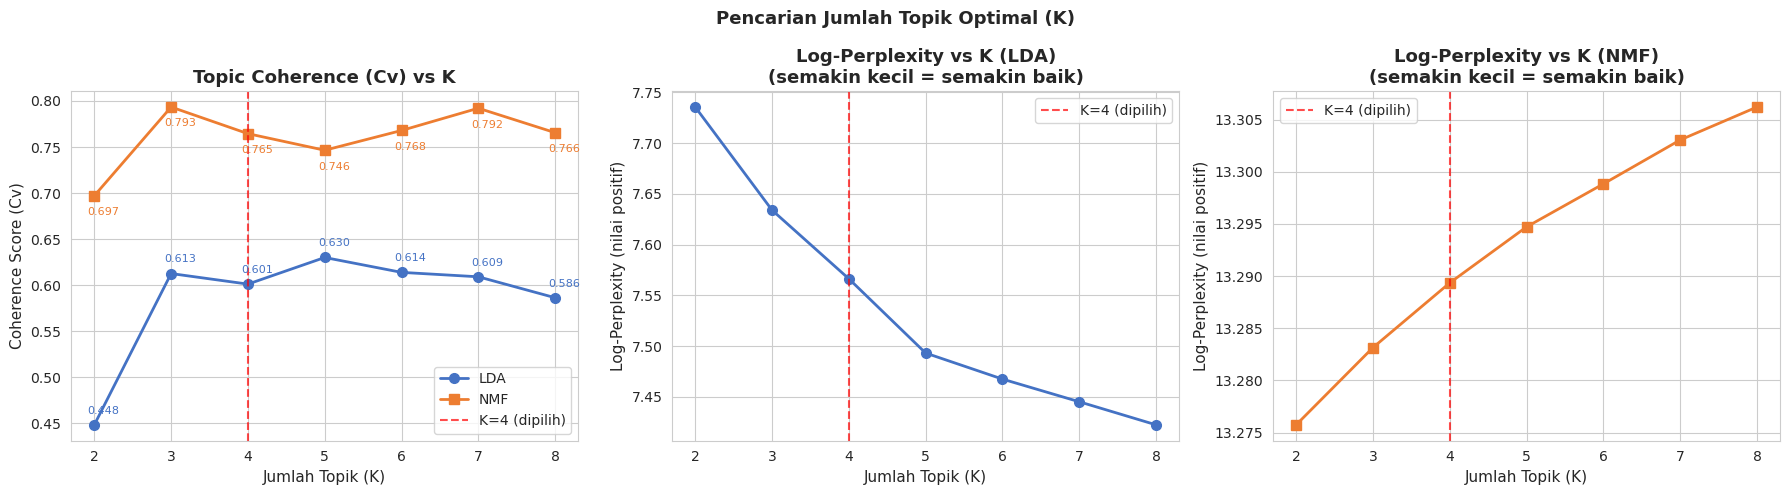


[OK] Grafik K optimal disimpan: 'output_hasil/grafik_k_optimal.png'


In [26]:
print("=" * 60)
print("  PENCARIAN JUMLAH TOPIK OPTIMAL (K)")
print("=" * 60)
print("  Menguji K = 2 hingga 8 ...\n")

K_RANGE = range(2, 9)

id2word_k    = corpora.Dictionary(token_list)
id2word_k.filter_extremes(no_below=5, no_above=0.85)
corpus_bow_k = [id2word_k.doc2bow(doc) for doc in token_list]

lda_coherence_k  = []
nmf_coherence_k  = []
lda_logperp_k    = []   # Log-Perplexity LDA (POSITIF, semakin kecil = semakin baik)
nmf_logperp_k    = []   # Log-Perplexity NMF (POSITIF, berbasis reconstruction error)

for k in K_RANGE:
    print(f"  Menguji K = {k} ...", end=" ")

    lda_k = LdaModel(
        corpus              = corpus_bow_k,
        id2word             = id2word_k,
        num_topics          = k,
        random_state        = RANDOM_SEED,
        passes              = 20,
        iterations          = 100,
        alpha               = 50 / k,
        eta                 = 0.1,
        minimum_probability = 0.0,
    )

    cv_lda = CoherenceModel(
        model      = lda_k,
        texts      = token_list,
        dictionary = id2word_k,
        coherence  = "c_v",
        topn       = 10,
    ).get_coherence()

    # Gensim log_perplexity() mengembalikan per-word log-likelihood (NEGATIF).
    # Log-Perplexity yang benar = -log_likelihood (POSITIF).
    # Semakin KECIL (positif) = model semakin BAIK.
    log_perp_lda = -lda_k.log_perplexity(corpus_bow_k)   # POSITIF
    lda_coherence_k.append(cv_lda)
    lda_logperp_k.append(log_perp_lda)

    nmf_k = NMF(
        n_components = k,
        init         = "random",
        max_iter     = 200,
        random_state = RANDOM_SEED,
    )
    W_k = nmf_k.fit_transform(tfidf_matrix)
    H_k = nmf_k.components_

    nmf_topics_k = [
        [vocab[j] for j in H_k[i].argsort()[::-1][:10]]
        for i in range(k)
    ]
    cv_nmf = CoherenceModel(
        topics     = nmf_topics_k,
        texts      = token_list,
        dictionary = id2word_k,
        coherence  = "c_v",
    ).get_coherence()
    nmf_coherence_k.append(cv_nmf)

    # Log-Perplexity NMF: -log(reconstruction_error_per_elemen)
    # Semakin KECIL (positif) = rekonstruksi makin akurat = model makin baik.
    recon_err    = nmf_k.reconstruction_err_
    n_elements   = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
    norm_err     = recon_err / n_elements
    log_perp_nmf = -np.log(norm_err + 1e-10)   # POSITIF (tanda minus di depan)
    nmf_logperp_k.append(log_perp_nmf)

    print(f"LDA Cv={cv_lda:.4f} | NMF Cv={cv_nmf:.4f} | LogPerp-LDA={log_perp_lda:.4f} | LogPerp-NMF={log_perp_nmf:.4f}")

print("\n" + "="*78)
print(f"  {'K':<5} {'LDA Cv':>10} {'NMF Cv':>10} {'Log-Perp LDA':>14} {'Log-Perp NMF':>14}")
print("  " + "-"*74)
for i, k in enumerate(K_RANGE):
    mark = " <- K dipilih" if k == Config.N_TOPICS else ""
    print(f"  {k:<5} {lda_coherence_k[i]:>10.4f} {nmf_coherence_k[i]:>10.4f} "
          f"{lda_logperp_k[i]:>14.4f} {nmf_logperp_k[i]:>14.4f}{mark}")
print("="*78)
print("  Catatan: Log-Perplexity bernilai POSITIF -> semakin KECIL = semakin BAIK")

k_opt_lda = list(K_RANGE)[np.argmax(lda_coherence_k)]
k_opt_nmf = list(K_RANGE)[np.argmax(nmf_coherence_k)]
print(f"\n  K dengan Coherence tertinggi:")
print(f"    LDA -> K = {k_opt_lda}  (Cv = {max(lda_coherence_k):.4f})")
print(f"    NMF -> K = {k_opt_nmf}  (Cv = {max(nmf_coherence_k):.4f})")
print(f"\n  Penelitian ini menggunakan K = {Config.N_TOPICS} sesuai jumlah kategori dataset.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pencarian Jumlah Topik Optimal (K)", fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.plot(list(K_RANGE), lda_coherence_k, "o-", color="#4472C4", linewidth=2, markersize=7, label="LDA")
ax1.plot(list(K_RANGE), nmf_coherence_k, "s-", color="#ED7D31", linewidth=2, markersize=7, label="NMF")
ax1.axvline(x=Config.N_TOPICS, color="red", linestyle="--", alpha=0.7, label=f"K={Config.N_TOPICS} (dipilih)")
ax1.set_title("Topic Coherence (Cv) vs K", fontweight="bold")
ax1.set_xlabel("Jumlah Topik (K)")
ax1.set_ylabel("Coherence Score (Cv)")
ax1.set_xticks(list(K_RANGE))
ax1.legend()
for i, k in enumerate(K_RANGE):
    ax1.annotate(f"{lda_coherence_k[i]:.3f}", (k, lda_coherence_k[i]),
                 textcoords="offset points", xytext=(-5, 8), fontsize=8, color="#4472C4")
    ax1.annotate(f"{nmf_coherence_k[i]:.3f}", (k, nmf_coherence_k[i]),
                 textcoords="offset points", xytext=(-5, -14), fontsize=8, color="#ED7D31")

ax2 = axes[1]
ax2.plot(list(K_RANGE), lda_logperp_k, "o-", color="#4472C4", linewidth=2, markersize=7)
ax2.axvline(x=Config.N_TOPICS, color="red", linestyle="--", alpha=0.7, label=f"K={Config.N_TOPICS} (dipilih)")
ax2.set_title("Log-Perplexity vs K (LDA)\n(semakin kecil = semakin baik)", fontweight="bold")
ax2.set_xlabel("Jumlah Topik (K)")
ax2.set_ylabel("Log-Perplexity (nilai positif)")
ax2.set_xticks(list(K_RANGE))
ax2.legend()

ax3 = axes[2]
ax3.plot(list(K_RANGE), nmf_logperp_k, "s-", color="#ED7D31", linewidth=2, markersize=7)
ax3.axvline(x=Config.N_TOPICS, color="red", linestyle="--", alpha=0.7, label=f"K={Config.N_TOPICS} (dipilih)")
ax3.set_title("Log-Perplexity vs K (NMF)\n(semakin kecil = semakin baik)", fontweight="bold")
ax3.set_xlabel("Jumlah Topik (K)")
ax3.set_ylabel("Log-Perplexity (nilai positif)")
ax3.set_xticks(list(K_RANGE))
ax3.legend()

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/grafik_k_optimal.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[OK] Grafik K optimal disimpan: '{Config.OUTPUT_DIR}/grafik_k_optimal.png'")


6. PEMODELAN TOPIK: LDA (GENSIM)

In [27]:
print("\n[STEP 4] Pemodelan LDA...")

token_list   = df["tokens"].tolist()
id2word      = corpora.Dictionary(token_list)
id2word.filter_extremes(no_below=Config.TFIDF_MIN_DF, no_above=Config.TFIDF_MAX_DF)
corpus_bow   = [id2word.doc2bow(doc) for doc in token_list]

t_lda_start = time.time()

lda_model = LdaModel(
    corpus         = corpus_bow,
    id2word        = id2word,
    num_topics     = Config.N_TOPICS,
    random_state   = RANDOM_SEED,
    passes         = Config.LDA_PASSES,
    iterations     = Config.LDA_ITERATIONS,
    alpha          = Config.LDA_ALPHA,
    eta            = Config.LDA_ETA,
    per_word_topics= True,
)

t_lda_end = time.time()
lda_waktu = t_lda_end - t_lda_start
print(f"   LDA selesai dalam {lda_waktu:.1f} detik.")

print("\n   === TOPIK YANG DIHASILKAN LDA ===")
rows_lda = []
for i in range(Config.N_TOPICS):
    top_terms = lda_model.show_topic(i, topn=Config.N_TOP_WORDS)
    kata_str  = ", ".join([w for w, _ in top_terms][:Config.N_TOP_WORDS])
    print(f"   Topik {i+1}: {kata_str}")
    rows_lda.append({"topik": f"Topik {i+1}", "kata_dominan": kata_str})

coherence_lda_model = CoherenceModel(
    model=lda_model, texts=token_list, dictionary=id2word, coherence="c_v"
)
coherence_lda_avg  = coherence_lda_model.get_coherence()
coherence_lda_list = coherence_lda_model.get_coherence_per_topic()

print(f"\n   Rata-rata Topic Coherence (Cv) LDA : {coherence_lda_avg:.4f}")
for i, cv in enumerate(coherence_lda_list):
    print(f"   Topik {i+1} Coherence: {cv:.4f}")

for i, row in enumerate(rows_lda):
    row["coherence_cv"] = round(coherence_lda_list[i], 4) if i < len(coherence_lda_list) else None

# Gensim log_perplexity() mengembalikan per-word log-LIKELIHOOD (nilai negatif).
# Log-Perplexity yang benar dalam literatur = -log_likelihood (nilai POSITIF).
# Rumus: Log-Perplexity = log(Perplexity) = -1/N * sum(log p(w))
# Semakin KECIL (positif) = model semakin BAIK.
log_perplexity_lda = -lda_model.log_perplexity(corpus_bow)   # POSITIF
perplexity_lda     = np.exp(log_perplexity_lda)              # exp(log_perp)

print(f"\n   Log-Perplexity LDA : {log_perplexity_lda:.4f}  (nilai POSITIF, semakin kecil = semakin baik)")
print(f"   Perplexity LDA     : {perplexity_lda:.2f}")
print(f"   Interpretasi: semakin KECIL Log-Perplexity = model semakin mampu memahami dokumen")

def get_dominant_topic_lda(bow_doc):
    dist = lda_model.get_document_topics(bow_doc, minimum_probability=0)
    dist_sorted = sorted(dist, key=lambda x: x[1], reverse=True)
    return dist_sorted[0][0], round(dist_sorted[0][1], 4)

df["lda_topik_dominan"], df["lda_prob_dominan"] = zip(
    *[get_dominant_topic_lda(bow) for bow in corpus_bow]
)

df_lda = pd.DataFrame(rows_lda)
df_lda.to_csv(f"{Config.OUTPUT_DIR}/hasil_topik_lda.csv", index=False, encoding="utf-8-sig")
print(f"\n   [OK] Hasil LDA disimpan ke '{Config.OUTPUT_DIR}/hasil_topik_lda.csv'")



[STEP 4] Pemodelan LDA...
   LDA selesai dalam 110.3 detik.

   === TOPIK YANG DIHASILKAN LDA ===
   Topik 1: prabowo, presiden, indonesia, perintah, daerah, negara, dpr, menteri, barat, ketua
   Topik 2: indonesia, piala, main, tim, final, hasil, kalah, gelar, asia, tanding
   Topik 3: teknologi, digital, indonesia, milik, hadir, sistem, anak, kuat, data, guna
   Topik 4: ekonomi, indonesia, harga, tahun, tingkat, perintah, tumbuh, kuat, pasar, energi

   Rata-rata Topic Coherence (Cv) LDA : 0.4830
   Topik 1 Coherence: 0.4430
   Topik 2 Coherence: 0.5945
   Topik 3 Coherence: 0.3663
   Topik 4 Coherence: 0.5284

   Log-Perplexity LDA : 10.1399  (nilai POSITIF, semakin kecil = semakin baik)
   Perplexity LDA     : 25332.81
   Interpretasi: semakin KECIL Log-Perplexity = model semakin mampu memahami dokumen

   [OK] Hasil LDA disimpan ke 'output_hasil/hasil_topik_lda.csv'


7. PEMODELAN TOPIK: NMF (SCIKIT-LEARN)

In [28]:
print("\n[STEP 5] Pemodelan NMF...")

t_nmf_start = time.time()

nmf_model = NMF(
    n_components = Config.N_TOPICS,
    init         = Config.NMF_INIT,
    max_iter     = Config.NMF_MAX_ITER,
    solver       = Config.NMF_SOLVER,
    random_state = RANDOM_SEED,
    l1_ratio     = 0.0,
)

W = nmf_model.fit_transform(tfidf_matrix)
H = nmf_model.components_

t_nmf_end  = time.time()
nmf_waktu  = t_nmf_end - t_nmf_start
print(f"   NMF selesai dalam {nmf_waktu:.1f} detik.")

print("\n   === TOPIK YANG DIHASILKAN NMF ===")
rows_nmf = []
nmf_topics_terms = []
for i, topic_vec in enumerate(H):
    top_idx     = topic_vec.argsort()[::-1][:Config.N_TOP_WORDS]
    top_words_i = [vocab[j] for j in top_idx]
    kata_str    = ", ".join(top_words_i)
    print(f"   Topik {i+1}: {kata_str}")
    rows_nmf.append({"topik": f"Topik {i+1}", "kata_dominan": kata_str})
    nmf_topics_terms.append(top_words_i)

coherence_nmf_model = CoherenceModel(
    topics=nmf_topics_terms, texts=token_list, dictionary=id2word, coherence="c_v"
)
coherence_nmf_avg  = coherence_nmf_model.get_coherence()
coherence_nmf_list = coherence_nmf_model.get_coherence_per_topic()

print(f"\n   Rata-rata Topic Coherence (Cv) NMF : {coherence_nmf_avg:.4f}")
for i, cv in enumerate(coherence_nmf_list):
    print(f"   Topik {i+1} Coherence: {cv:.4f}")

for i, row in enumerate(rows_nmf):
    row["coherence_cv"] = round(coherence_nmf_list[i], 4) if i < len(coherence_nmf_list) else None

# Log-Perplexity NMF berbasis Reconstruction Error (Frobenius norm)
# NMF bukan model probabilistik, sehingga tidak ada log_perplexity() bawaan.
# Pendekatan: -log(reconstruction_error / n_elemen) -> nilai POSITIF
# Semakin KECIL = rekonstruksi makin akurat = model makin baik.
recon_err          = nmf_model.reconstruction_err_
n_elements         = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
norm_recon_err     = recon_err / n_elements
log_perplexity_nmf = -np.log(norm_recon_err + 1e-10)   # POSITIF (tanda minus)

print(f"\n   Log-Perplexity NMF  : {log_perplexity_nmf:.4f}  (nilai POSITIF, semakin kecil = semakin baik)")
print(f"   Reconstruction Err  : {recon_err:.4f}  (Frobenius norm ||X - WH||)")
print(f"   Interpretasi: semakin KECIL Log-Perplexity = rekonstruksi makin akurat")
print(f"   Catatan: Log-Perplexity LDA dan NMF dihitung dengan cara berbeda,")
print(f"            tidak dapat dibandingkan langsung satu sama lain.")

W_norm = normalize(W, norm="l1")
df["nmf_topik_dominan"] = W.argmax(axis=1)
df["nmf_bobot_dominan"] = W.max(axis=1).round(4)

df_nmf = pd.DataFrame(rows_nmf)
df_nmf.to_csv(f"{Config.OUTPUT_DIR}/hasil_topik_nmf.csv", index=False, encoding="utf-8-sig")
print(f"\n   [OK] Hasil NMF disimpan ke '{Config.OUTPUT_DIR}/hasil_topik_nmf.csv'")



[STEP 5] Pemodelan NMF...
   NMF selesai dalam 0.5 detik.

   === TOPIK YANG DIHASILKAN NMF ===
   Topik 1: piala, indonesia, final, futsal, kalah, jadwal, aff, thailand, asia, main
   Topik 2: ekonomi, tumbuh, harga, indonesia, perintah, kuat, pasar, global, ojk, tahun
   Topik 3: misi, nasa, burung, artemis, teliti, kulit, darat, adang, rem, bumi
   Topik 4: prabowo, presiden, daerah, perintah, teddy, politeknik, partai, dpr, negara, disabilitas

   Rata-rata Topic Coherence (Cv) NMF : 0.7645
   Topik 1 Coherence: 0.9130
   Topik 2 Coherence: 0.5503
   Topik 3 Coherence: 0.9860
   Topik 4 Coherence: 0.6087

   Log-Perplexity NMF  : 13.2893  (nilai POSITIF, semakin kecil = semakin baik)
   Reconstruction Err  : 60.2670  (Frobenius norm ||X - WH||)
   Interpretasi: semakin KECIL Log-Perplexity = rekonstruksi makin akurat
   Catatan: Log-Perplexity LDA dan NMF dihitung dengan cara berbeda,
            tidak dapat dibandingkan langsung satu sama lain.

   [OK] Hasil NMF disimpan ke 'out

8. EVALUASI & PERBANDINGAN

In [29]:
print("\n[STEP 6] Evaluasi & Perbandingan...")

total_lda = lda_waktu
total_nmf = nmf_waktu

print("\n" + "="*65)
print("  TABEL PERBANDINGAN HASIL LDA vs NMF")
print("="*65)
print(f"  {'Indikator':<40} {'LDA':>12} {'NMF':>12}")
print("-"*65)

for i in range(Config.N_TOPICS):
    lda_cv = coherence_lda_list[i] if i < len(coherence_lda_list) else float('nan')
    nmf_cv = coherence_nmf_list[i] if i < len(coherence_nmf_list) else float('nan')
    print(f"  {f'Coherence Topik {i+1}':<40} {lda_cv:>12.4f} {nmf_cv:>12.4f}")

print("-"*65)
print(f"  {'Rata-rata Coherence (Cv)':<40} {coherence_lda_avg:>12.4f} {coherence_nmf_avg:>12.4f}")
print(f"  {'Waktu Komputasi (detik)':<40} {total_lda:>12.1f} {total_nmf:>12.1f}")
print(f"  {'Log-Perplexity':<40} {log_perplexity_lda:>12.4f} {log_perplexity_nmf:>12.4f}")
print("="*65)
print("  * Log-Perplexity bernilai POSITIF -> semakin KECIL = semakin BAIK")
print("  * LDA: berbasis log-probabilitas kata  | NMF: berbasis reconstruction error")
print("  * Tidak dapat dibandingkan langsung antar metode")

print("\n" + "="*65)
print("  PENJELASAN LOG-PERPLEXITY")
print("="*65)
print(f"  Log-Perplexity LDA : {log_perplexity_lda:.4f}  (POSITIF)")
print(f"  Log-Perplexity NMF : {log_perplexity_nmf:.4f}  (POSITIF)")
print()
print("  Definisi:")
print("  Log-Perplexity = log(Perplexity) = -1/N * sum(log p(w))")
print("  Nilainya selalu POSITIF karena ada tanda minus di depan.")
print()
print("  Perhatian terkait Gensim:")
print("  Fungsi lda.log_perplexity() mengembalikan per-word log-LIKELIHOOD")
print("  (nilai negatif). Untuk mendapatkan Log-Perplexity yang benar,")
print("  harus dikalikan -1: Log-Perplexity = -lda.log_perplexity()")
print()
print("  Interpretasi:")
print("  Semakin KECIL Log-Perplexity -> model semakin BAIK")

if log_perplexity_lda < 400:
    interp_lda = "SANGAT BAIK - model LDA sangat mampu memahami dokumen"
elif log_perplexity_lda < 700:
    interp_lda = "BAIK - model LDA cukup mampu memahami dokumen"
elif log_perplexity_lda < 1000:
    interp_lda = "CUKUP - pertimbangkan peningkatan parameter"
else:
    interp_lda = "PERLU DITINGKATKAN - tambah passes/iterasi"

print(f"\n  Kesimpulan LDA : {interp_lda}")
print("="*65)

pemenang = "NMF" if coherence_nmf_avg > coherence_lda_avg else "LDA"
print(f"\n  Metode dengan Coherence lebih tinggi : {pemenang}")
print(f"    LDA Cv = {coherence_lda_avg:.4f} | NMF Cv = {coherence_nmf_avg:.4f}")

compare_data = []
for i in range(Config.N_TOPICS):
    lda_cv = coherence_lda_list[i] if i < len(coherence_lda_list) else None
    nmf_cv = coherence_nmf_list[i] if i < len(coherence_nmf_list) else None
    compare_data.append({
        "topik": f"Topik {i+1}",
        "coherence_lda": round(lda_cv, 4) if lda_cv else None,
        "coherence_nmf": round(nmf_cv, 4) if nmf_cv else None,
        "selisih": round(nmf_cv - lda_cv, 4) if (lda_cv and nmf_cv) else None,
    })
compare_data.append({
    "topik": "RATA-RATA",
    "coherence_lda": round(coherence_lda_avg, 4),
    "coherence_nmf": round(coherence_nmf_avg, 4),
    "selisih": round(coherence_nmf_avg - coherence_lda_avg, 4),
})
compare_data.append({
    "topik": "LOG-PERPLEXITY (positif, kecil=baik)",
    "coherence_lda": round(log_perplexity_lda, 4),
    "coherence_nmf": round(log_perplexity_nmf, 4),
    "selisih": "tidak dapat dibandingkan langsung",
})
df_compare = pd.DataFrame(compare_data)
df_compare.to_csv(f"{Config.OUTPUT_DIR}/perbandingan_coherence.csv", index=False, encoding="utf-8-sig")
print(f"\n  [OK] Tabel perbandingan disimpan ke '{Config.OUTPUT_DIR}/perbandingan_coherence.csv'")



[STEP 6] Evaluasi & Perbandingan...

  TABEL PERBANDINGAN HASIL LDA vs NMF
  Indikator                                         LDA          NMF
-----------------------------------------------------------------
  Coherence Topik 1                              0.4430       0.9130
  Coherence Topik 2                              0.5945       0.5503
  Coherence Topik 3                              0.3663       0.9860
  Coherence Topik 4                              0.5284       0.6087
-----------------------------------------------------------------
  Rata-rata Coherence (Cv)                       0.4830       0.7645
  Waktu Komputasi (detik)                         110.3          0.5
  Log-Perplexity                                10.1399      13.2893
  * Log-Perplexity bernilai POSITIF -> semakin KECIL = semakin BAIK
  * LDA: berbasis log-probabilitas kata  | NMF: berbasis reconstruction error
  * Tidak dapat dibandingkan langsung antar metode

  PENJELASAN LOG-PERPLEXITY
  Log-Perplexi

9. VISUALISASI


[STEP 7] Membuat Visualisasi...


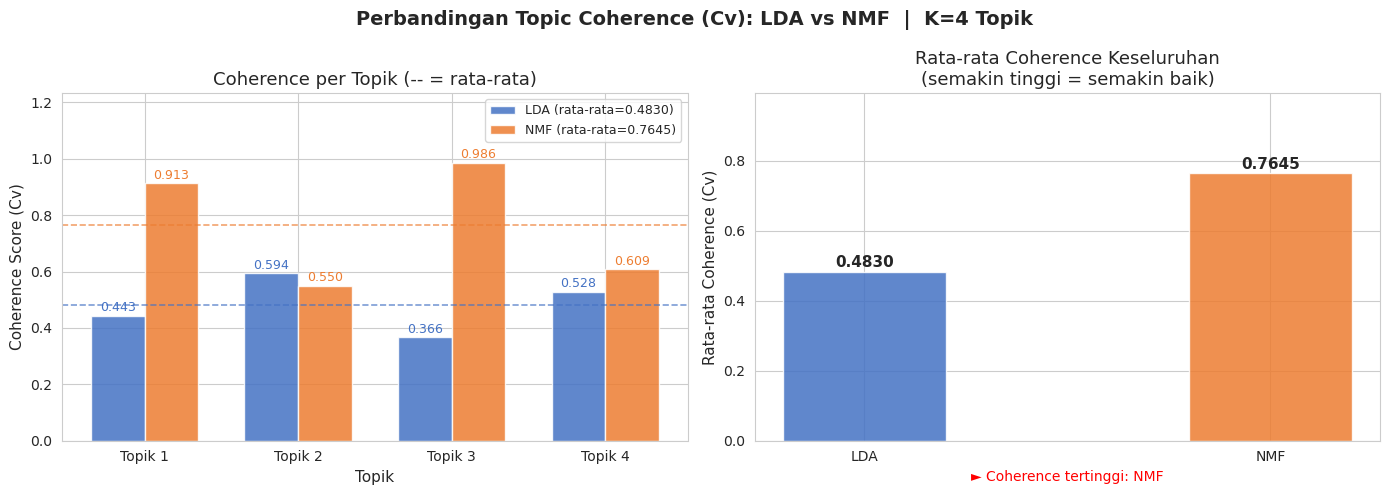

   [✓] 'output_hasil/grafik_coherence_comparison.png'


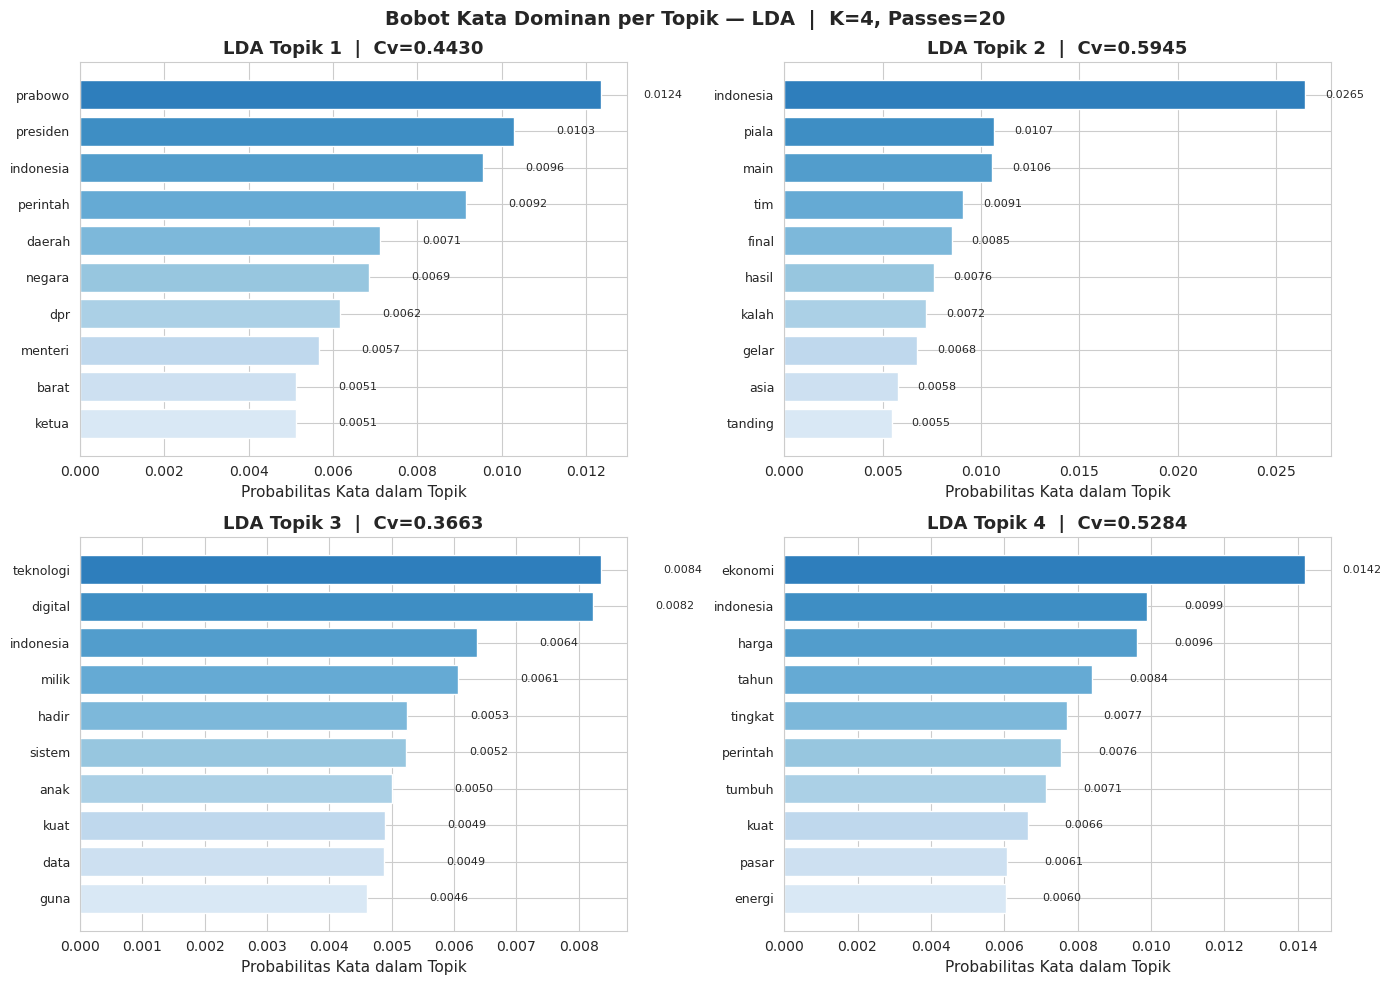

   [✓] 'output_hasil/grafik_topik_lda.png'


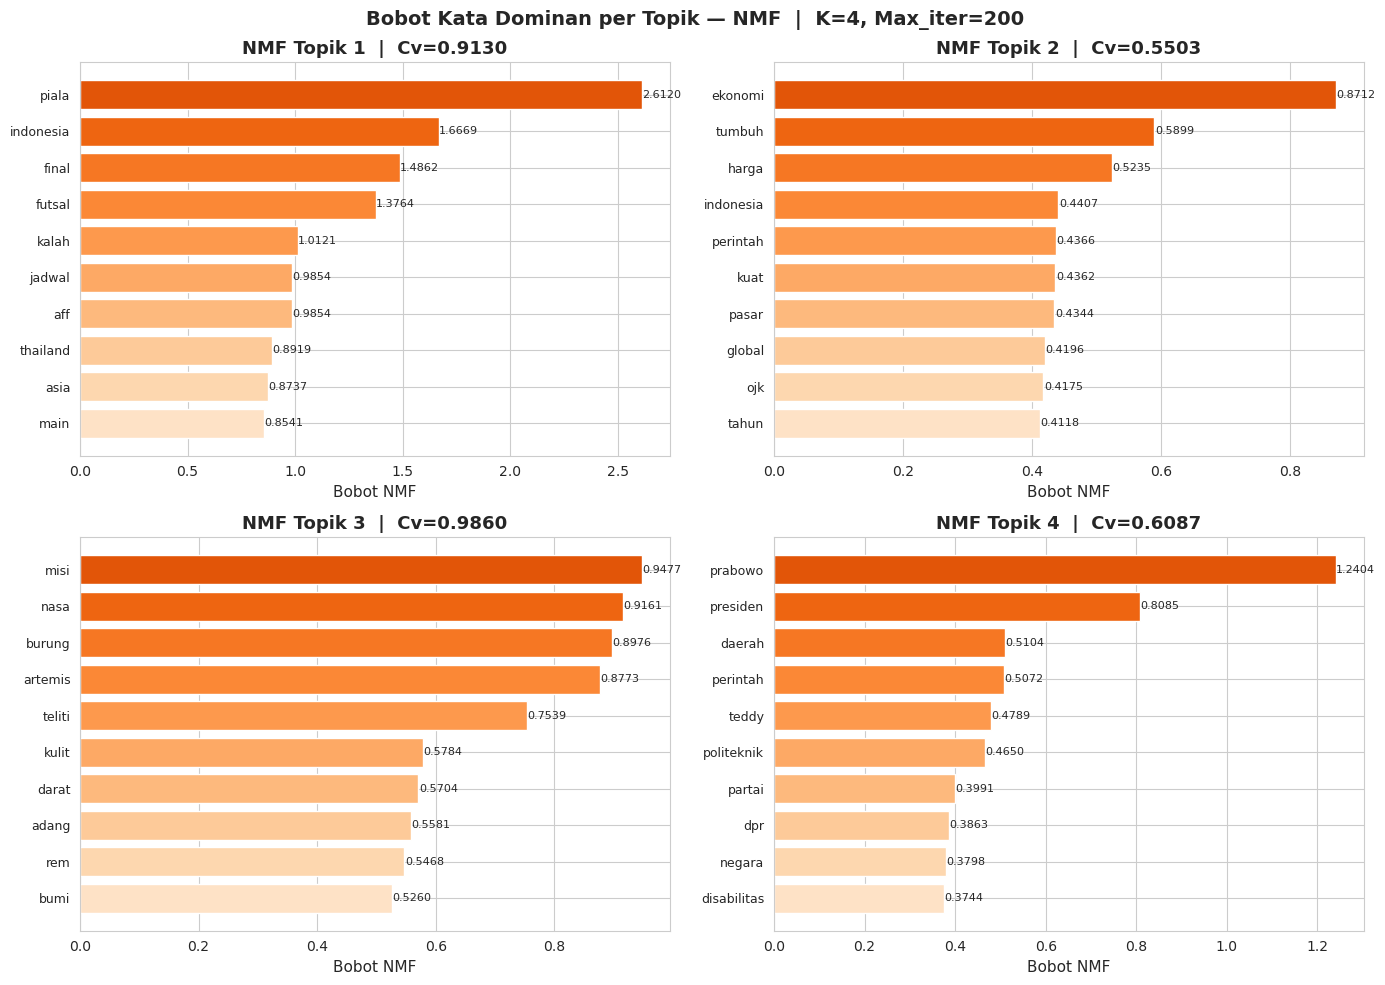

   [✓] 'output_hasil/grafik_topik_nmf.png'


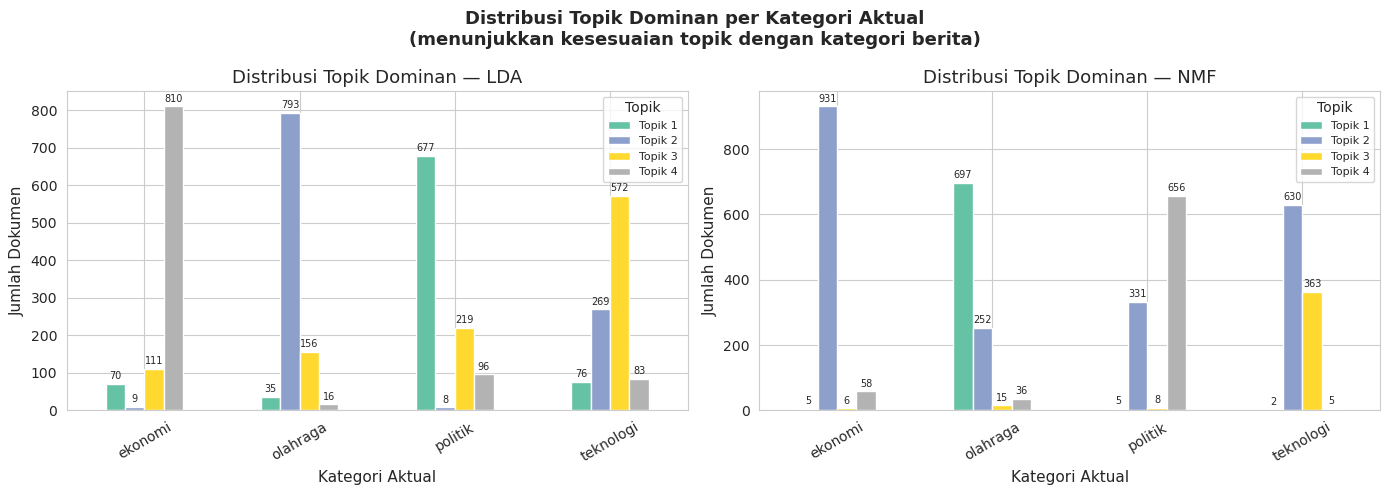

   [✓] 'output_hasil/grafik_distribusi_topik.png'


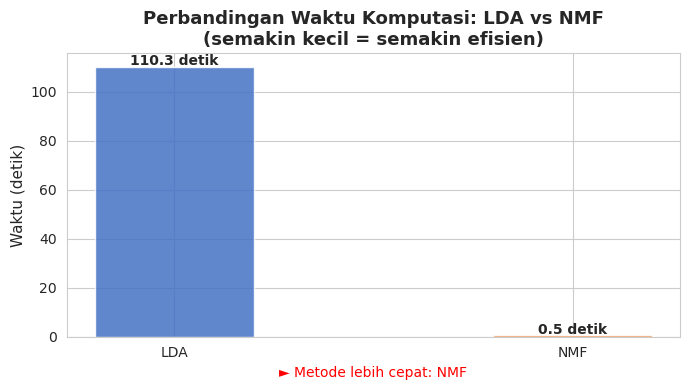

   [✓] 'output_hasil/grafik_waktu_komputasi.png'


In [30]:
print("\n[STEP 7] Membuat Visualisasi...")

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family"   : "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── 9.1 Grafik perbandingan coherence (bar chart) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Perbandingan Topic Coherence (Cv): LDA vs NMF  |  K={Config.N_TOPICS} Topik",
    fontsize=14, fontweight="bold"
)

labels_topik = [f"Topik {i+1}" for i in range(Config.N_TOPICS)]
x     = np.arange(len(labels_topik))
width = 0.35

lda_cvs = [coherence_lda_list[i] if i < len(coherence_lda_list) else 0 for i in range(Config.N_TOPICS)]
nmf_cvs = [coherence_nmf_list[i] if i < len(coherence_nmf_list) else 0 for i in range(Config.N_TOPICS)]

# Grouped bar per topik
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, lda_cvs, width, label=f"LDA (rata-rata={coherence_lda_avg:.4f})", color="#4472C4", alpha=0.85)
bars2 = ax1.bar(x + width/2, nmf_cvs, width, label=f"NMF (rata-rata={coherence_nmf_avg:.4f})", color="#ED7D31", alpha=0.85)

# Tambah garis rata-rata
ax1.axhline(y=coherence_lda_avg, color="#4472C4", linestyle="--", linewidth=1.2, alpha=0.7)
ax1.axhline(y=coherence_nmf_avg, color="#ED7D31", linestyle="--", linewidth=1.2, alpha=0.7)

ax1.set_xlabel("Topik")
ax1.set_ylabel("Coherence Score (Cv)")
ax1.set_title("Coherence per Topik (-- = rata-rata)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels_topik)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(max(lda_cvs), max(nmf_cvs)) * 1.25)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, color="#4472C4")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, color="#ED7D31")

# Bar rata-rata keseluruhan
ax2 = axes[1]
metode  = ["LDA", "NMF"]
avg_cvs = [coherence_lda_avg, coherence_nmf_avg]
colors  = ["#4472C4", "#ED7D31"]
bars = ax2.bar(metode, avg_cvs, color=colors, width=0.4, alpha=0.85)
ax2.set_ylabel("Rata-rata Coherence (Cv)")
ax2.set_title("Rata-rata Coherence Keseluruhan\n(semakin tinggi = semakin baik)")
ax2.set_ylim(0, max(avg_cvs) * 1.3)

# Tambah keterangan pemenang
pemenang = "NMF" if coherence_nmf_avg > coherence_lda_avg else "LDA"
ax2.set_xlabel(f"► Coherence tertinggi: {pemenang}", fontsize=10, color="red")

for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
path_coh = f"{Config.OUTPUT_DIR}/grafik_coherence_comparison.png"
plt.savefig(path_coh, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] '{path_coh}'")

# ── 9.2 Grafik bobot kata dominan per topik (LDA) ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Bobot Kata Dominan per Topik — LDA  |  K={Config.N_TOPICS}, Passes={Config.LDA_PASSES}",
    fontsize=14, fontweight="bold"
)
axes_flat = axes.flatten()

for i in range(Config.N_TOPICS):
    ax          = axes_flat[i]
    topic_words = lda_model.show_topic(i, topn=10)
    words, probs = zip(*topic_words)
    colors_bar  = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(words)))
    bars_h = ax.barh(list(reversed(words)), list(reversed(probs)), color=colors_bar[::-1])
    ax.set_title(
        f"LDA Topik {i+1}  |  Cv={coherence_lda_list[i]:.4f}",   # ← tambah nilai Cv
        fontweight="bold"
    )
    ax.set_xlabel("Probabilitas Kata dalam Topik")
    ax.tick_params(axis="y", labelsize=9)
    # Tambah label angka di tiap bar
    for bar, prob in zip(bars_h, list(reversed(probs))):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{prob:.4f}", va="center", fontsize=8)

plt.tight_layout()
path_lda_plot = f"{Config.OUTPUT_DIR}/grafik_topik_lda.png"
plt.savefig(path_lda_plot, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] '{path_lda_plot}'")

# ── 9.3 Grafik bobot kata dominan per topik (NMF) ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Bobot Kata Dominan per Topik — NMF  |  K={Config.N_TOPICS}, Max_iter={Config.NMF_MAX_ITER}",
    fontsize=14, fontweight="bold"
)
axes_flat = axes.flatten()

for i in range(Config.N_TOPICS):
    ax      = axes_flat[i]
    top_idx = H[i].argsort()[::-1][:10]
    words   = [vocab[j] for j in top_idx]
    scores  = [H[i][j] for j in top_idx]
    colors_bar = plt.cm.Oranges_r(np.linspace(0.3, 0.85, len(words)))
    bars_h = ax.barh(list(reversed(words)), list(reversed(scores)), color=colors_bar[::-1])
    ax.set_title(
        f"NMF Topik {i+1}  |  Cv={coherence_nmf_list[i]:.4f}",   # ← tambah nilai Cv
        fontweight="bold"
    )
    ax.set_xlabel("Bobot NMF")
    ax.tick_params(axis="y", labelsize=9)
    # Tambah label angka di tiap bar
    for bar, score in zip(bars_h, list(reversed(scores))):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{score:.4f}", va="center", fontsize=8)

plt.tight_layout()
path_nmf_plot = f"{Config.OUTPUT_DIR}/grafik_topik_nmf.png"
plt.savefig(path_nmf_plot, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] '{path_nmf_plot}'")

# ── 9.4 Distribusi topik dominan per kategori ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Distribusi Topik Dominan per Kategori Aktual\n(menunjukkan kesesuaian topik dengan kategori berita)",
    fontsize=13, fontweight="bold"
)

for ax, (col, label) in zip(axes, [("lda_topik_dominan", "LDA"), ("nmf_topik_dominan", "NMF")]):
    crosstab = pd.crosstab(df[Config.COL_KATEGORI], df[col])
    crosstab.columns = [f"Topik {c+1}" for c in crosstab.columns]
    crosstab.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"Distribusi Topik Dominan — {label}")
    ax.set_xlabel("Kategori Aktual")
    ax.set_ylabel("Jumlah Dokumen")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Topik", fontsize=8)
    # Tambah label angka di tiap bar ← BARU
    for container in ax.containers:
        ax.bar_label(container, fontsize=7, padding=2)

plt.tight_layout()
path_dist = f"{Config.OUTPUT_DIR}/grafik_distribusi_topik.png"
plt.savefig(path_dist, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] '{path_dist}'")

# ── 9.5 Grafik waktu komputasi ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ["LDA", "NMF"], [total_lda, total_nmf],
    color=["#4472C4", "#ED7D31"], width=0.4, alpha=0.85
)
ax.set_title(
    "Perbandingan Waktu Komputasi: LDA vs NMF\n(semakin kecil = semakin efisien)",
    fontweight="bold"
)
ax.set_ylabel("Waktu (detik)")
ax.set_xlabel(f"► Metode lebih cepat: {'NMF' if total_nmf < total_lda else 'LDA'}", color="red", fontsize=10)
for i, v in enumerate([total_lda, total_nmf]):
    ax.text(i, v + 0.5, f"{v:.1f} detik", ha="center", fontweight="bold")

plt.tight_layout()
path_waktu = f"{Config.OUTPUT_DIR}/grafik_waktu_komputasi.png"
plt.savefig(path_waktu, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] '{path_waktu}'")

10. WordCloud per Topik


[TAMBAHAN 1] WordCloud per Topik...


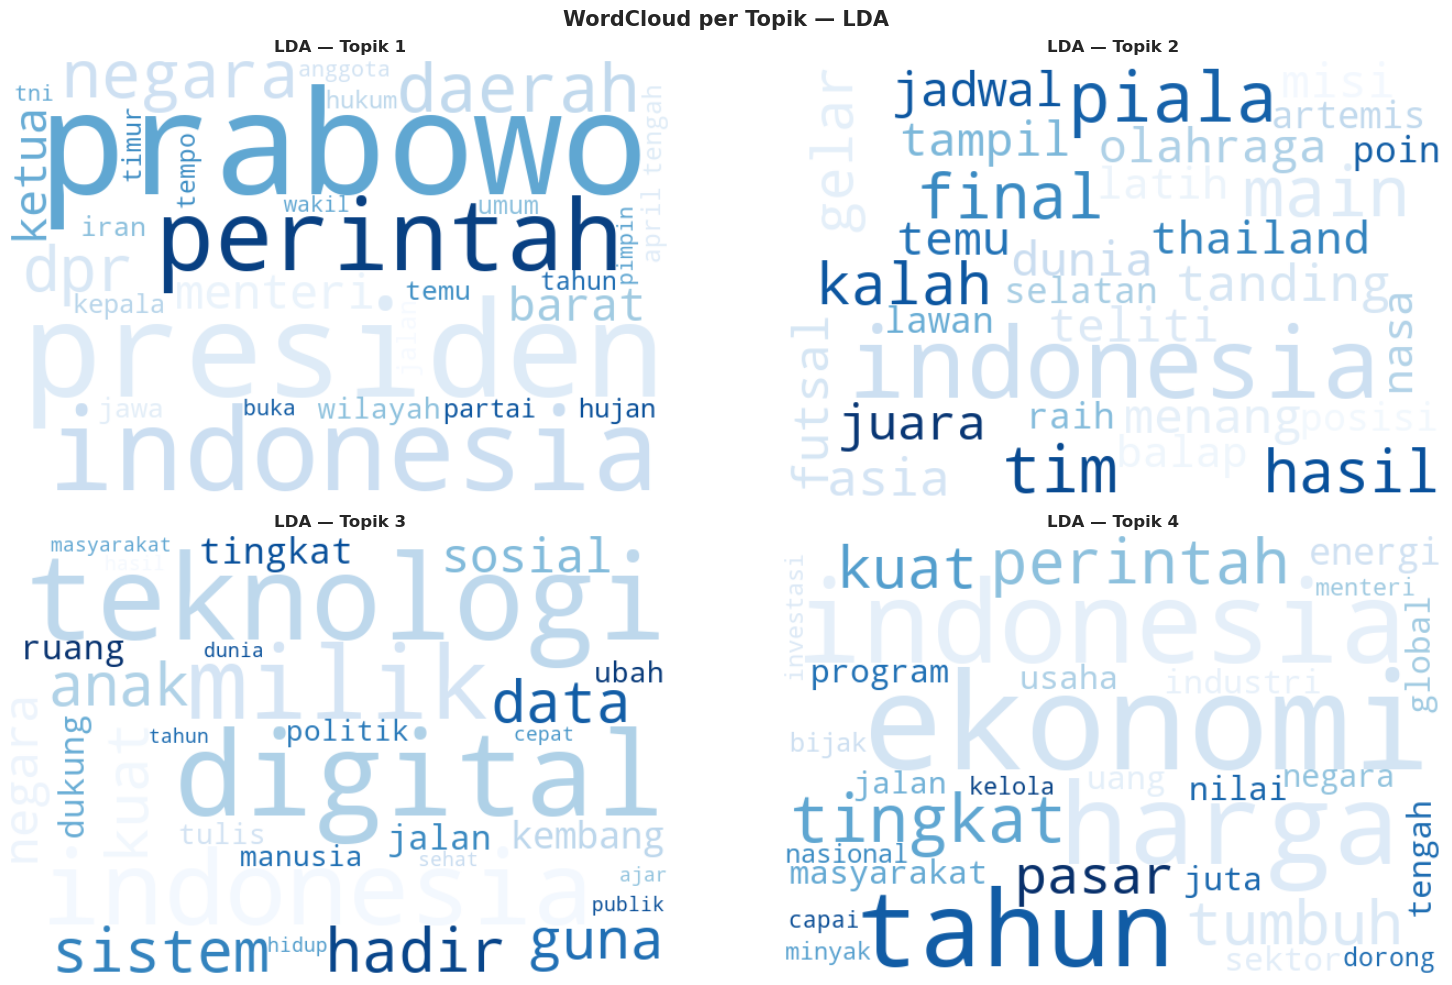

   [✓] WordCloud LDA disimpan: 'output_hasil/wordcloud_lda.png'


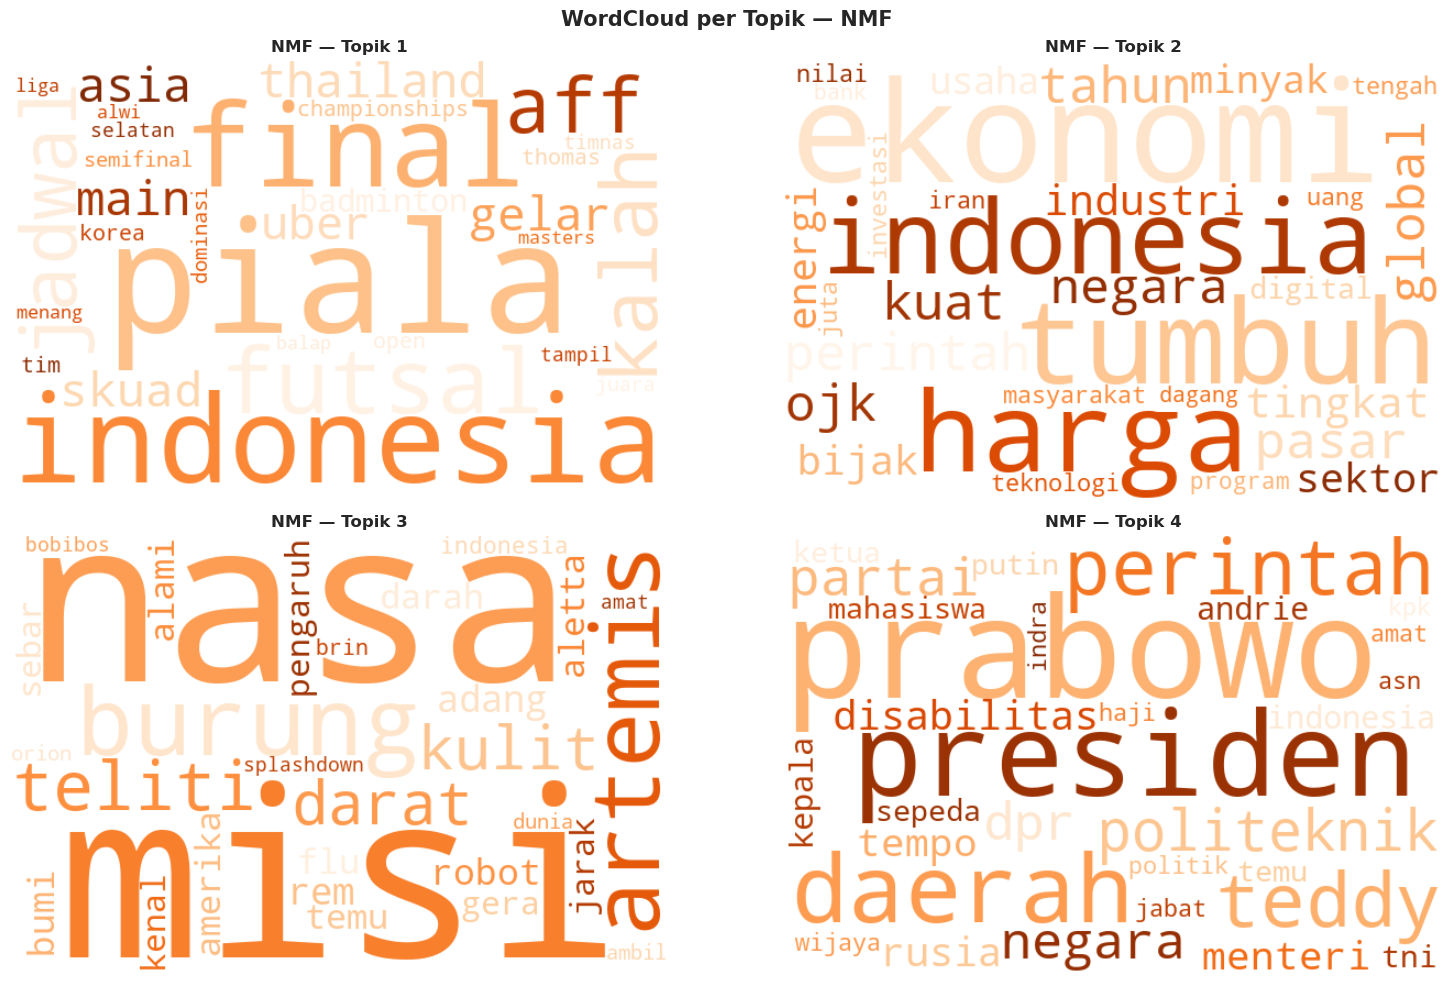

   [✓] WordCloud NMF disimpan: 'output_hasil/wordcloud_nmf.png'


In [31]:
 
from wordcloud import WordCloud
 
print("\n[TAMBAHAN 1] WordCloud per Topik...")
 
# ── WordCloud LDA ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("WordCloud per Topik — LDA", fontsize=15, fontweight="bold")
axes_flat = axes.flatten()
 
for i in range(Config.N_TOPICS):
    # Ambil kata + bobot dari model LDA
    topic_words = lda_model.show_topic(i, topn=30)
    word_freq   = {word: float(prob) for word, prob in topic_words}
 
    wc = WordCloud(
        width            = 600,
        height           = 400,
        background_color = "white",
        colormap         = "Blues",
        max_words        = 30,
        prefer_horizontal= 0.9,
    ).generate_from_frequencies(word_freq)
 
    axes_flat[i].imshow(wc, interpolation="bilinear")
    axes_flat[i].axis("off")
    axes_flat[i].set_title(f"LDA — Topik {i+1}", fontweight="bold", fontsize=12)
 
plt.tight_layout()
path_wc_lda = f"{Config.OUTPUT_DIR}/wordcloud_lda.png"
plt.savefig(path_wc_lda, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] WordCloud LDA disimpan: '{path_wc_lda}'")
 
# ── WordCloud NMF ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("WordCloud per Topik — NMF", fontsize=15, fontweight="bold")
axes_flat = axes.flatten()
 
for i in range(Config.N_TOPICS):
    # Ambil kata + bobot dari matriks H (komponen NMF)
    top_idx    = H[i].argsort()[::-1][:30]
    word_freq  = {vocab[j]: float(H[i][j]) for j in top_idx}
 
    wc = WordCloud(
        width            = 600,
        height           = 400,
        background_color = "white",
        colormap         = "Oranges",
        max_words        = 30,
        prefer_horizontal= 0.9,
    ).generate_from_frequencies(word_freq)
 
    axes_flat[i].imshow(wc, interpolation="bilinear")
    axes_flat[i].axis("off")
    axes_flat[i].set_title(f"NMF — Topik {i+1}", fontweight="bold", fontsize=12)
 
plt.tight_layout()
path_wc_nmf = f"{Config.OUTPUT_DIR}/wordcloud_nmf.png"
plt.savefig(path_wc_nmf, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] WordCloud NMF disimpan: '{path_wc_nmf}'")

11. Tabel dokumen sampel per topik

In [32]:

print("\n[TAMBAHAN 2] Tabel Dokumen Sampel per Topik...")
 
N_SAMPEL = 3   # jumlah sampel dokumen per topik yang ditampilkan
 
# ── Sampel LDA ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  DOKUMEN SAMPEL PER TOPIK — LDA")
print("="*60)
 
rows_sampel_lda = []
for topik_id in range(Config.N_TOPICS):
    # Ambil dokumen yang topik dominannya = topik_id
    mask      = df["lda_topik_dominan"] == topik_id
    df_topik  = df[mask].nlargest(N_SAMPEL, "lda_prob_dominan")
 
    # Kata dominan topik ini
    kata_topik = ", ".join([w for w, _ in lda_model.show_topic(topik_id, topn=5)])
    print(f"\n  Topik {topik_id+1}  |  Kata dominan: {kata_topik}")
    print("  " + "-"*55)
 
    for _, row in df_topik.iterrows():
        judul    = str(row.get(Config.COL_JUDUL, row[Config.COL_ISI]))[:80]
        kategori = row[Config.COL_KATEGORI]
        prob     = row["lda_prob_dominan"]
        print(f"  [{kategori}]  prob={prob:.3f}  {judul}...")
        rows_sampel_lda.append({
            "topik"       : f"Topik {topik_id+1}",
            "model"       : "LDA",
            "kategori"    : kategori,
            "probabilitas": round(prob, 4),
            "judul"       : judul,
        })
 
# ── Sampel NMF ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  DOKUMEN SAMPEL PER TOPIK — NMF")
print("="*60)
 
rows_sampel_nmf = []
for topik_id in range(Config.N_TOPICS):
    mask      = df["nmf_topik_dominan"] == topik_id
    df_topik  = df[mask].nlargest(N_SAMPEL, "nmf_bobot_dominan")
 
    top_idx    = H[topik_id].argsort()[::-1][:5]
    kata_topik = ", ".join([vocab[j] for j in top_idx])
    print(f"\n  Topik {topik_id+1}  |  Kata dominan: {kata_topik}")
    print("  " + "-"*55)
 
    for _, row in df_topik.iterrows():
        judul    = str(row.get(Config.COL_JUDUL, row[Config.COL_ISI]))[:80]
        kategori = row[Config.COL_KATEGORI]
        bobot    = row["nmf_bobot_dominan"]
        print(f"  [{kategori}]  bobot={bobot:.3f}  {judul}...")
        rows_sampel_nmf.append({
            "topik"   : f"Topik {topik_id+1}",
            "model"   : "NMF",
            "kategori": kategori,
            "bobot"   : round(bobot, 4),
            "judul"   : judul,
        })
 
# Simpan ke CSV
df_sampel = pd.DataFrame(rows_sampel_lda + rows_sampel_nmf)
path_sampel = f"{Config.OUTPUT_DIR}/sampel_dokumen_per_topik.csv"
df_sampel.to_csv(path_sampel, index=False, encoding="utf-8-sig")
print(f"\n   [✓] Tabel sampel dokumen disimpan: '{path_sampel}'")


[TAMBAHAN 2] Tabel Dokumen Sampel per Topik...

  DOKUMEN SAMPEL PER TOPIK — LDA

  Topik 1  |  Kata dominan: prabowo, presiden, indonesia, perintah, daerah
  -------------------------------------------------------
  [politik]  prob=0.999  Langkah Andrie Yunus usai Kasusnya Dilimpahkan ke Puspom TNI...
  [politik]  prob=0.999  Koalisi: TGPF Lebih Penting dari Usulan Bentuk Hakim Ad Hoc...
  [politik]  prob=0.999  Kata Komnas HAM soal Usul Gibran Libatkan Hakim Ad Hoc di Kasus Andrie...

  Topik 2  |  Kata dominan: indonesia, piala, main, tim, final
  -------------------------------------------------------
  [olahraga]  prob=0.999  Jadwal BATC 2026: Tim Putri Indonesia vs Korea Selatan Sabtu...
  [olahraga]  prob=0.999  Catatan PBSI setelah Raih 4 Gelar di Thailand Masters 2026...
  [olahraga]  prob=0.999  Hasil All England 2026: 6 Wakil Indonesia ke Perempat Final...

  Topik 3  |  Kata dominan: teknologi, digital, indonesia, milik, hadir
  --------------------------------------------

12. Confusion matrix topik vs kategori 


[TAMBAHAN 3] Confusion Matrix Topik vs Kategori...


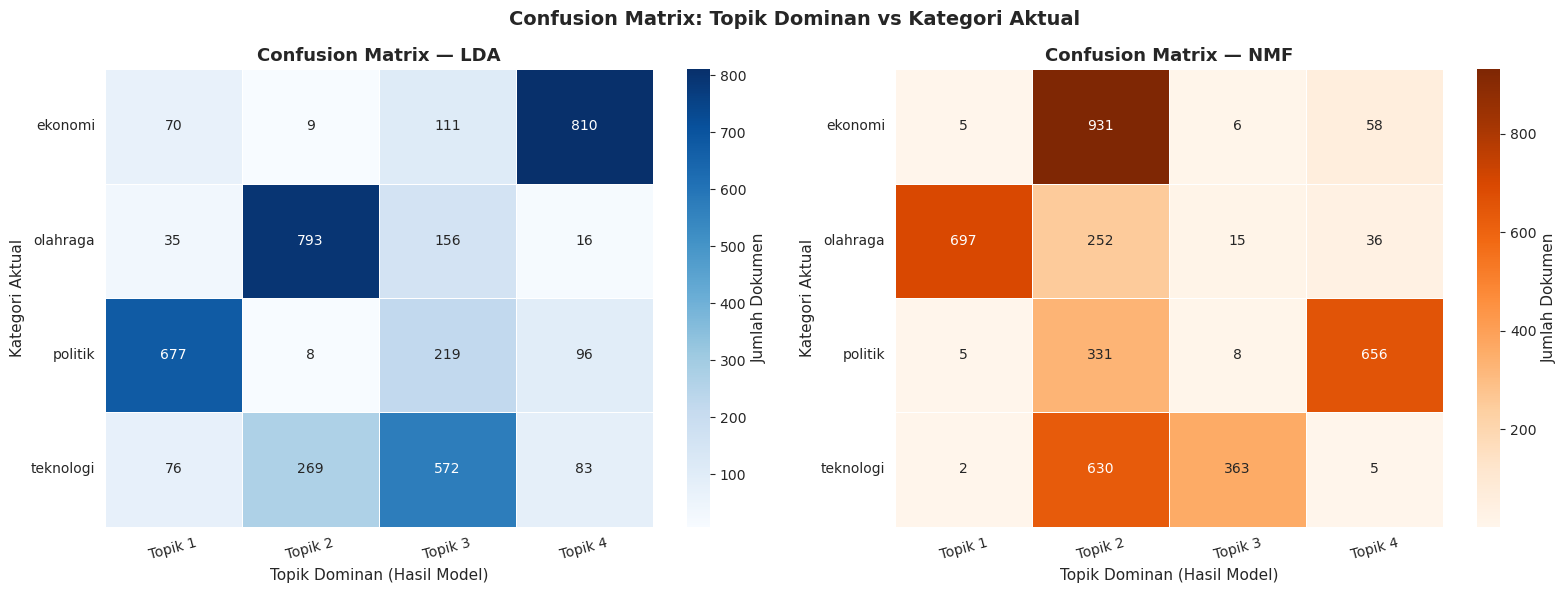

   [✓] Confusion matrix disimpan: 'output_hasil/confusion_matrix_topik_vs_kategori.png'
   [✓] Tabel confusion matrix LDA disimpan: 'output_hasil/confusion_matrix_lda.csv'
   [✓] Tabel confusion matrix NMF disimpan: 'output_hasil/confusion_matrix_nmf.csv'


In [33]:
print("\n[TAMBAHAN 3] Confusion Matrix Topik vs Kategori...")
 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
# Label kategori aktual yang unik (urut abjad agar konsisten)
label_kategori = sorted(df[Config.COL_KATEGORI].unique())
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix: Topik Dominan vs Kategori Aktual",
             fontsize=14, fontweight="bold")
 
for ax, (col_topik, label_model, cmap) in zip(
    axes,
    [
        ("lda_topik_dominan", "LDA", "Blues"),
        ("nmf_topik_dominan", "NMF", "Oranges"),
    ]
):
    # Buat label topik (0-based → "Topik 1", dst)
    label_topik = [f"Topik {i+1}" for i in range(Config.N_TOPICS)]
 
    # Hitung crosstab: baris = kategori aktual, kolom = topik prediksi
    ct = pd.crosstab(
        df[Config.COL_KATEGORI],   # baris = kategori nyata
        df[col_topik].map(lambda x: f"Topik {x+1}"),  # kolom = topik model
        rownames=["Kategori Aktual"],
        colnames=["Topik Model"],
    )
    # Pastikan semua topik muncul sebagai kolom
    for t in label_topik:
        if t not in ct.columns:
            ct[t] = 0
    ct = ct[label_topik]   # urut kolom
 
    # Tampilkan sebagai heatmap
    sns.heatmap(
        ct,
        annot      = True,
        fmt        = "d",
        cmap       = cmap,
        linewidths = 0.5,
        ax         = ax,
        cbar_kws   = {"label": "Jumlah Dokumen"},
    )
    ax.set_title(f"Confusion Matrix — {label_model}", fontweight="bold")
    ax.set_xlabel("Topik Dominan (Hasil Model)")
    ax.set_ylabel("Kategori Aktual")
    ax.tick_params(axis="x", rotation=15)
    ax.tick_params(axis="y", rotation=0)
 
plt.tight_layout()
path_cm = f"{Config.OUTPUT_DIR}/confusion_matrix_topik_vs_kategori.png"
plt.savefig(path_cm, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"   [✓] Confusion matrix disimpan: '{path_cm}'")
 
# ── Simpan juga ke CSV ────────────────────────────────────────────────────────
for col_topik, nama in [("lda_topik_dominan", "lda"), ("nmf_topik_dominan", "nmf")]:
    ct_csv = pd.crosstab(
        df[Config.COL_KATEGORI],
        df[col_topik].map(lambda x: f"Topik {x+1}"),
        rownames=["kategori_aktual"],
        colnames=["topik_model"],
    )
    path_ct = f"{Config.OUTPUT_DIR}/confusion_matrix_{nama}.csv"
    ct_csv.to_csv(path_ct, encoding="utf-8-sig")
    print(f"   [✓] Tabel confusion matrix {nama.upper()} disimpan: '{path_ct}'")

13. LAPORAN RINGKASAN AKHIR

In [34]:
print("\n" + "="*70)
print("                     LAPORAN RINGKASAN AKHIR")
print("="*70)

metode_unggul = "NMF" if coherence_nmf_avg > coherence_lda_avg else "LDA"
metode_lebih_cepat = "NMF" if total_nmf < total_lda else "LDA"

stemming_terbaik_lda = (
    "Dengan Stemming"
    if results["Dengan Stemming"]["LDA_Coherence"] > results["Tanpa Stemming"]["LDA_Coherence"]
    else "Tanpa Stemming"
)
stemming_terbaik_nmf = (
    "Dengan Stemming"
    if results["Dengan Stemming"]["NMF_Coherence"] > results["Tanpa Stemming"]["NMF_Coherence"]
    else "Tanpa Stemming"
)

print(f"""
DATASET
Jumlah dokumen          : {len(df):,}
Jumlah kategori         : {df[Config.COL_KATEGORI].nunique()}
Kategori                : {", ".join(sorted(df[Config.COL_KATEGORI].unique()))}
Total token bersih      : {len(all_tokens_after.dropna()):,}
Vocabulary TF-IDF       : {len(vocab):,} kata
Jumlah topik (K)        : {Config.N_TOPICS}

HASIL LDA (K={Config.N_TOPICS})
Rata-rata Coherence (Cv): {coherence_lda_avg:.4f}
Log-Perplexity          : {log_perplexity_lda:.4f}  (POSITIF, semakin kecil = semakin baik)
Perplexity              : {perplexity_lda:.2f}
Waktu komputasi         : {total_lda:.2f} detik

HASIL NMF (K={Config.N_TOPICS})
Rata-rata Coherence (Cv): {coherence_nmf_avg:.4f}
Log-Perplexity          : {log_perplexity_nmf:.4f}  (POSITIF, semakin kecil = semakin baik)
                          (berbasis reconstruction error Frobenius norm)
Waktu komputasi         : {total_nmf:.2f} detik

CATATAN LOG-PERPLEXITY
Log-Perplexity = log(Perplexity) = -1/N * sum(log p(w))
Nilainya POSITIF. Semakin KECIL = model semakin baik.
Gensim log_perplexity() mengembalikan log-likelihood (negatif),
sehingga perlu dikalikan -1 untuk mendapat Log-Perplexity yang benar.

PERBANDINGAN STEMMING vs TANPA STEMMING
LDA  - Dengan stemming  : {results["Dengan Stemming"]["LDA_Coherence"]:.4f}
LDA  - Tanpa stemming   : {results["Tanpa Stemming"]["LDA_Coherence"]:.4f}
     Pipeline terbaik   : {stemming_terbaik_lda}
NMF  - Dengan stemming  : {results["Dengan Stemming"]["NMF_Coherence"]:.4f}
NMF  - Tanpa stemming   : {results["Tanpa Stemming"]["NMF_Coherence"]:.4f}
     Pipeline terbaik   : {stemming_terbaik_nmf}

KESIMPULAN
Metode unggul (Cv)      : {metode_unggul}
Selisih Coherence       : {abs(coherence_nmf_avg - coherence_lda_avg):.4f}
Metode lebih cepat      : {metode_lebih_cepat}
""")

print("="*70)
print("SELESAI - Semua hasil berhasil disimpan.")
print("="*70)



                     LAPORAN RINGKASAN AKHIR

DATASET
Jumlah dokumen          : 4,000
Jumlah kategori         : 4
Kategori                : ekonomi, olahraga, politik, teknologi
Total token bersih      : 1,048,201
Vocabulary TF-IDF       : 8,903 kata
Jumlah topik (K)        : 4

HASIL LDA (K=4)
Rata-rata Coherence (Cv): 0.4830
Log-Perplexity          : 10.1399  (POSITIF, semakin kecil = semakin baik)
Perplexity              : 25332.81
Waktu komputasi         : 110.28 detik

HASIL NMF (K=4)
Rata-rata Coherence (Cv): 0.7645
Log-Perplexity          : 13.2893  (POSITIF, semakin kecil = semakin baik)
                          (berbasis reconstruction error Frobenius norm)
Waktu komputasi         : 0.54 detik

CATATAN LOG-PERPLEXITY
Log-Perplexity = log(Perplexity) = -1/N * sum(log p(w))
Nilainya POSITIF. Semakin KECIL = model semakin baik.
Gensim log_perplexity() mengembalikan log-likelihood (negatif),
sehingga perlu dikalikan -1 untuk mendapat Log-Perplexity yang benar.

PERBANDINGAN STEM